# 05_01 — Grid Search Multi-parâmetro com Features FFT

**Pipeline:** `fft_model_training` (configuração via `conf/base/parameters.yml`)  
**Features:** geradas pelo pipeline `fft_feature_engineering` (notebook `02_01`) → `data/04_feature_fft/`  
**Foco:** Otimização simultânea de `contamination`, `n_estimators`, `max_features` e `max_samples`

---

## Diferença em relação ao 03_01

O notebook `03_01` usa as features clássicas de `data/04_feature/` (rolling stats sobre todos
os sinais preparados). Este notebook usa exclusivamente as **features espectrais e de rolling**
geradas pelo pipeline `fft_feature_engineering` sobre os 7 sinais com vínculo físico direto
à frequência de rotação do motor:

| Família | Descriptores | Janelas |
|---|---|---|
| Rolling statistics | `mean`, `std`, `slope` | [50, 100, 200] amostras (~0.25–1 s) |
| FFT spectral | `peak_power`, `entropy`, `high_ratio` | [500, 1000, 2000] amostras (~2.5–10 s) |

A hipótese é que features espectrais capturam **precursores de falha** invisíveis no domínio
do tempo — oscilações periódicas na frequência de rotação do motor antes da parada completa.

## Parâmetros explorados

| Parâmetro | Default | O que controla |
|---|---|---|
| `contamination` | 0.01 | Fração de anomalias assumida → determina o limiar de decisão |
| `n_estimators` | 100 | Número de árvores → estabilidade do score |
| `max_features` | 1.0 | Fração de features por árvore → diversidade do ensemble |
| `max_samples` | auto=256 | Amostras por árvore → velocidade vs estabilidade |

## Estratégia de busca eficiente

`contamination` não afeta a construção das árvores — apenas o limiar de decisão.
Por isso, para cada combinação `(n_estimators, max_features, max_samples)` o modelo
é treinado **uma única vez** e os diferentes valores de `contamination` são avaliados
ajustando o percentil do `score_samples` no conjunto de treino. Isso reduz o número
de treinamentos de `N×M×K×C` para `N×M×K`.

## Imports e parâmetros

In [ ]:
import itertools
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.ensemble import IsolationForest

from aeroespacial_2.pipelines.model_training.nodes import (
    build_training_data,
    fit_and_scale,
)

warnings.filterwarnings("ignore")

_params = yaml.safe_load(
    (Path("../../conf/base/parameters.yml")).read_text()
)["fft_model_training"]

# Features FFT geradas pelo pipeline fft_feature_engineering (02_01)
FEATURE_DIR    = Path("../../data/04_feature_fft")
WINDOW_SIZE    = _params["window_size"]
N_TOP_FEATURES = _params["n_top_features"]
TRAIN_RATIO    = _params["train_ratio"]
TARGET_COL     = _params["target_col"]
TIMESTAMP_COL  = _params["timestamp_col"]
SKIP_SECONDS   = _params.get("skip_seconds", 0.0)

print("Parâmetros base (de parameters.yml → fft_model_training):")
for k, v in _params.items():
    print(f"  {k}: {v}")
print(f"\nDiretório de features: {FEATURE_DIR}")

## Carregamento e concatenação de todos os voos (features FFT)

Usa a mesma função `build_training_data` do pipeline Kedro, mas alimentada com os
CSVs de `data/04_feature/fft/` — saída do pipeline `fft_feature_engineering`.
A seleção de features, criação de janelas e split temporal são idênticos ao 03_01;
a única diferença é o conjunto de features disponíveis (espectral + rolling FFT).

In [2]:
csv_files = sorted(FEATURE_DIR.glob("*.csv"))
print(f"Voos encontrados: {len(csv_files)}")
for f in csv_files:
    print(f"  {f.name}")

Voos encontrados: 33
  carbonZ_2018-07-18-15-53-31_1_engine_failure.csv
  carbonZ_2018-07-18-15-53-31_2_engine_failure.csv
  carbonZ_2018-07-18-16-22-01_engine_failure_with_emr_traj.csv
  carbonZ_2018-07-18-16-37-39_1_no_failure.csv
  carbonZ_2018-07-18-16-37-39_2_engine_failure_with_emr_traj.csv
  carbonZ_2018-07-30-16-29-45_engine_failure_with_emr_traj.csv
  carbonZ_2018-07-30-16-39-00_1_engine_failure.csv
  carbonZ_2018-07-30-16-39-00_2_engine_failure.csv
  carbonZ_2018-07-30-16-39-00_3_no_failure.csv
  carbonZ_2018-07-30-17-10-45_engine_failure_with_emr_traj.csv
  carbonZ_2018-07-30-17-20-01_engine_failure_with_emr_traj.csv
  carbonZ_2018-07-30-17-36-35_engine_failure_with_emr_traj.csv
  carbonZ_2018-07-30-17-46-31_engine_failure_with_emr_traj.csv
  carbonZ_2018-09-11-11-56-30_engine_failure.csv
  carbonZ_2018-09-11-14-16-55_no_failure.csv
  carbonZ_2018-09-11-14-22-07_1_engine_failure.csv
  carbonZ_2018-09-11-14-22-07_2_engine_failure.csv
  carbonZ_2018-09-11-14-41-38_no_failure.c

In [3]:
prepared_flights = {f.stem: pd.read_csv(f) for f in csv_files}

print("Construindo dataset concatenado (features FFT)...")
t0 = time.time()

X_train, X_test, y_train, y_test, ts_test, top_features = build_training_data(
    prepared_flights=prepared_flights,
    window_size=WINDOW_SIZE,
    n_top_features=N_TOP_FEATURES,
    train_ratio=TRAIN_RATIO,
    target_col=TARGET_COL,
    timestamp_col=TIMESTAMP_COL,
    skip_seconds=SKIP_SECONDS,
)

X_train_scaled, X_test_scaled, scaler = fit_and_scale(X_train, X_test)

X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled  = X_test_scaled.astype(np.float32)

print(f"Concluído em {time.time() - t0:.1f}s")
print(f"\nDataset:")
print(f"  Train: {X_train.shape} | {int(y_train.sum())} falhas")
print(f"  Test:  {X_test.shape}  | {int(y_test.sum())} falhas")
print(f"  Features selecionadas ({N_TOP_FEATURES}): {top_features}")

Construindo dataset concatenado (features FFT)...
Concluído em 6.6s

Dataset:
  Train: (240278, 400) | 32976 falhas
  Test:  (102977, 400)  | 16535 falhas
  Features selecionadas (20): ['alt_global', 'imu_accel_x_mean_200', 'imu_accel_x_mean_100', 'imu_accel_x_mean_50', 'imu_accel_x', 'imu_accel_y_mean_200', 'imu_accel_y_mean_100', 'imu_accel_y_mean_50', 'imu_accel_y', 'fft_peak_power_imu_accel_x_2000', 'fft_entropy_mag_x_500', 'fft_entropy_imu_accel_z_1000', 'fft_high_ratio_mag_x_500', 'fft_entropy_imu_accel_z_2000', 'fft_high_ratio_mag_x_1000', 'fft_high_ratio_imu_accel_z_2000', 'fft_entropy_imu_accel_y_1000', 'fft_high_ratio_imu_accel_z_1000', 'fft_entropy_mag_z_1000', 'fft_peak_power_imu_accel_z_2000']


In [4]:
fault_indices = np.where(y_test == 1)[0]
assert len(fault_indices) > 0, "Nenhuma falha no conjunto de teste — ajuste train_ratio"

real_fault_idx  = fault_indices[0]
real_fault_time = float(ts_test[real_fault_idx])
pre_fault_mask  = ts_test < real_fault_time
n_pre_fault     = int(pre_fault_mask.sum())

print(f"Falha real no teste: t = {real_fault_time:.2f}s (idx {real_fault_idx})")
print(f"Janelas pré-falha no teste: {n_pre_fault} ({n_pre_fault / len(ts_test) * 100:.1f}% do test set)")

Falha real no teste: t = 48.18s (idx 2259)
Janelas pré-falha no teste: 33604 (32.6% do test set)


## Grid Search

Para cada combinação `(n_estimators, max_features, max_samples)`:
1. Treina o Isolation Forest uma única vez
2. Computa `score_samples` no treino e no teste
3. Para cada `contamination`, ajusta o limiar = percentil `contamination * 100` dos scores de treino
4. Avalia latência e falsos positivos

**Métricas registradas:**
- `latency_s`: segundos entre onset da falha e primeiro alerta (`None` = não detectou)
- `fp_count`: janelas pré-falha classificadas como anomalia
- `fp_rate`: `fp_count / n_pre_fault` — fração do período normal com alarmes falsos

In [5]:
PARAM_GRID = {
    "n_estimators": [150],
    "max_features": [0.7],
    "max_samples":  [128, 256],
    "contamination": [0.03],
}

tree_combos = list(itertools.product(
    PARAM_GRID["n_estimators"],
    PARAM_GRID["max_features"],
    PARAM_GRID["max_samples"],
))

n_total = len(tree_combos) * len(PARAM_GRID["contamination"])
print(f"Combinações de árvore:    {len(tree_combos)}")
print(f"Valores de contamination: {len(PARAM_GRID['contamination'])}")
print(f"Total de avaliações:      {n_total}")
print(f"Treinamentos efetivos:    {len(tree_combos)} (contamination reutiliza os scores)")

Combinações de árvore:    2
Valores de contamination: 1
Total de avaliações:      2
Treinamentos efetivos:    2 (contamination reutiliza os scores)


In [6]:
results = []
t0 = time.time()

for i, (n_est, max_feat, max_samp) in enumerate(tree_combos, 1):
    model = IsolationForest(
        n_estimators=n_est,
        max_features=max_feat,
        max_samples=max_samp,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train_scaled)

    train_scores = model.score_samples(X_train_scaled)
    test_scores  = model.score_samples(X_test_scaled)
    del model

    for c in PARAM_GRID["contamination"]:
        threshold = np.percentile(train_scores, 100 * c)
        y_pred    = (test_scores < threshold).astype(int)

        post_fault = np.where(
            (y_pred == 1) & (np.arange(len(y_pred)) >= real_fault_idx)
        )[0]
        latency = float(ts_test[post_fault[0]] - real_fault_time) if len(post_fault) > 0 else None

        fp_count = int(y_pred[pre_fault_mask].sum())
        fp_rate  = fp_count / n_pre_fault if n_pre_fault > 0 else 0.0

        results.append({
            "n_estimators": n_est,
            "max_features": max_feat,
            "max_samples":  max_samp,
            "contamination": c,
            "latency_s": latency,
            "fp_count":  fp_count,
            "fp_rate":   fp_rate,
        })

    elapsed = time.time() - t0
    eta = elapsed / i * (len(tree_combos) - i)
    print(f"[{i:2d}/{len(tree_combos)}] n_est={n_est:3d} max_feat={max_feat} "
          f"max_samp={max_samp:3d} | {elapsed:.0f}s decorridos, ETA {eta:.0f}s")

print(f"\nGrid search concluído em {time.time() - t0:.1f}s")
df_results = pd.DataFrame(results)
df_results.head()

[ 1/2] n_est=150 max_feat=0.7 max_samp=128 | 105s decorridos, ETA 105s
[ 2/2] n_est=150 max_feat=0.7 max_samp=256 | 209s decorridos, ETA 0s

Grid search concluído em 209.4s


,n_estimators,max_features,max_samples,contamination,latency_s,fp_count,fp_rate
0,150,0.7,128,0.03,0.894791,1607,0.047822
1,150,0.7,256,0.03,0.931250,2013,0.059904


## Análise dos resultados

### Score composto

Para ranquear as configurações, usamos um **score composto** que penaliza
tanto a latência quanto a taxa de falsos positivos:

$$\text{composite} = \text{latency\_s} \times (1 + 10 \times \text{fp\_rate})$$

Interpretação: uma `fp_rate` de 10% (1 em cada 10 janelas normais é alarme falso)
dobra o custo efetivo da latência. O fator 10 pode ser ajustado conforme
a tolerância operacional a falsos alarmes.

In [7]:
df_det = df_results.dropna(subset=["latency_s"]).copy()
df_det["composite"] = df_det["latency_s"] * (1 + 10 * df_det["fp_rate"])

n_no_detect = df_results["latency_s"].isna().sum()
print(f"Configurações que não detectaram a falha: {n_no_detect}/{len(df_results)}")
print(f"Configurações que detectaram:             {len(df_det)}/{len(df_results)}")
print()

top10 = (
    df_det
    .sort_values("composite")
    .head(10)
    [["contamination", "n_estimators", "max_features", "max_samples",
      "latency_s", "fp_count", "fp_rate", "composite"]]
    .reset_index(drop=True)
)
top10.index += 1
print("Top 10 configurações por score composto:")
top10.style.format({
    "latency_s": "{:.3f}s",
    "fp_rate": "{:.1%}",
    "composite": "{:.4f}",
})

Configurações que não detectaram a falha: 0/2
Configurações que detectaram:             2/2

Top 10 configurações por score composto:


,contamination,n_estimators,max_features,max_samples,latency_s,fp_count,fp_rate,composite
1,0.030000,150,0.700000,128,0.895s,1607,4.8%,1.3227
2,0.030000,150,0.700000,256,0.931s,2013,6.0%,1.4891


## Visualização: Frente de Pareto — Latência vs Falsos Positivos

Uma configuração é **Pareto-ótima** se nenhuma outra combinação tem
latência menor **e** taxa de FP menor simultaneamente.

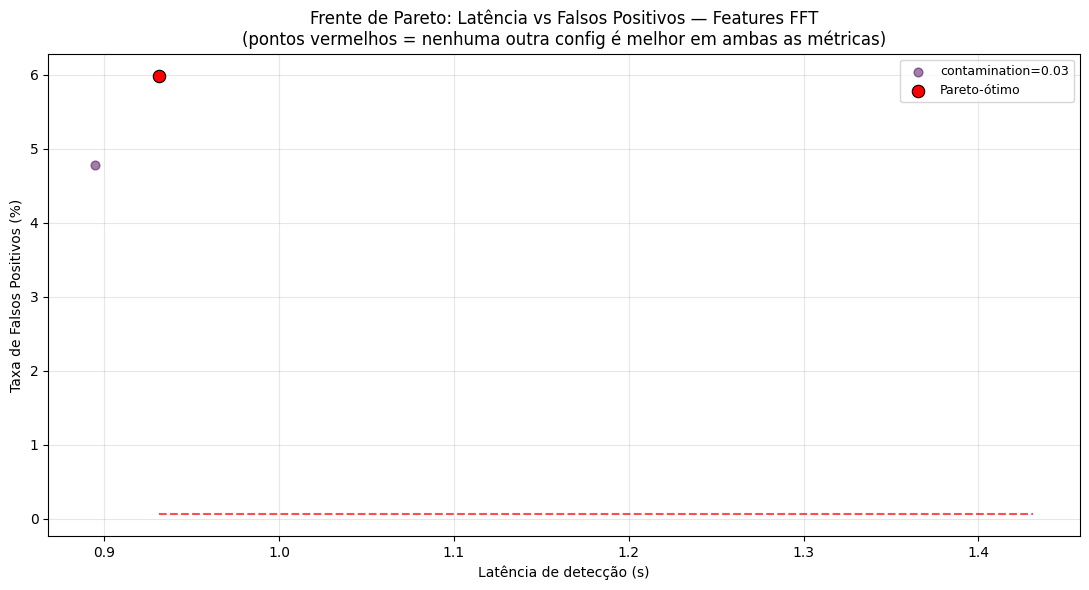

Configurações na frente de Pareto:
 contamination  n_estimators  max_features  max_samples  latency_s  fp_rate
          0.03           150           0.7          256    0.93125 0.059904


In [8]:
def pareto_front(df, x_col, y_col):
    """Retorna máscara booleana das linhas na frente de Pareto (minimização de ambos)."""
    is_pareto = np.ones(len(df), dtype=bool)
    vals = df[[x_col, y_col]].values
    for i, (xi, yi) in enumerate(vals):
        if is_pareto[i]:
            dominated = (
                (vals[:, 0] <= xi) & (vals[:, 1] <= yi)
                & ((vals[:, 0] < xi) | (vals[:, 1] < yi))
            )
            dominated[i] = False
            is_pareto[dominated] = False
    return is_pareto


df_det = df_det.reset_index(drop=True)
df_det["pareto"] = pareto_front(df_det, "latency_s", "fp_rate")

contamination_vals = sorted(df_det["contamination"].unique())
cmap   = plt.cm.viridis
colors = {c: cmap(i / max(len(contamination_vals) - 1, 1)) for i, c in enumerate(contamination_vals)}

fig, ax = plt.subplots(figsize=(11, 6))

for c, grp in df_det.groupby("contamination"):
    ax.scatter(
        grp["latency_s"], grp["fp_rate"] * 100,
        color=colors[c], alpha=0.5, s=40, label=f"contamination={c}",
    )

pareto = df_det[df_det["pareto"]].sort_values("latency_s")
ax.scatter(
    pareto["latency_s"], pareto["fp_rate"] * 100,
    color="red", s=80, zorder=5, label="Pareto-ótimo",
    edgecolors="black", linewidths=0.8,
)
ax.step(
    pareto["latency_s"].tolist() + [pareto["latency_s"].max() + 0.5],
    pareto["fp_rate"].tolist() + [pareto["fp_rate"].iloc[-1]],
    where="post", color="red", linewidth=1.5, linestyle="--", alpha=0.7,
)

ax.set_xlabel("Latência de detecção (s)")
ax.set_ylabel("Taxa de Falsos Positivos (%)")
ax.set_title(
    "Frente de Pareto: Latência vs Falsos Positivos — Features FFT\n"
    "(pontos vermelhos = nenhuma outra config é melhor em ambas as métricas)"
)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Configurações na frente de Pareto:")
print(pareto[["contamination", "n_estimators", "max_features", "max_samples",
              "latency_s", "fp_rate"]].to_string(index=False))

## Impacto individual de cada parâmetro

Para entender a contribuição de cada parâmetro isoladamente,
agrupamos os resultados e calculamos a mediana da latência e do FP rate,
agregando sobre todos os outros parâmetros.

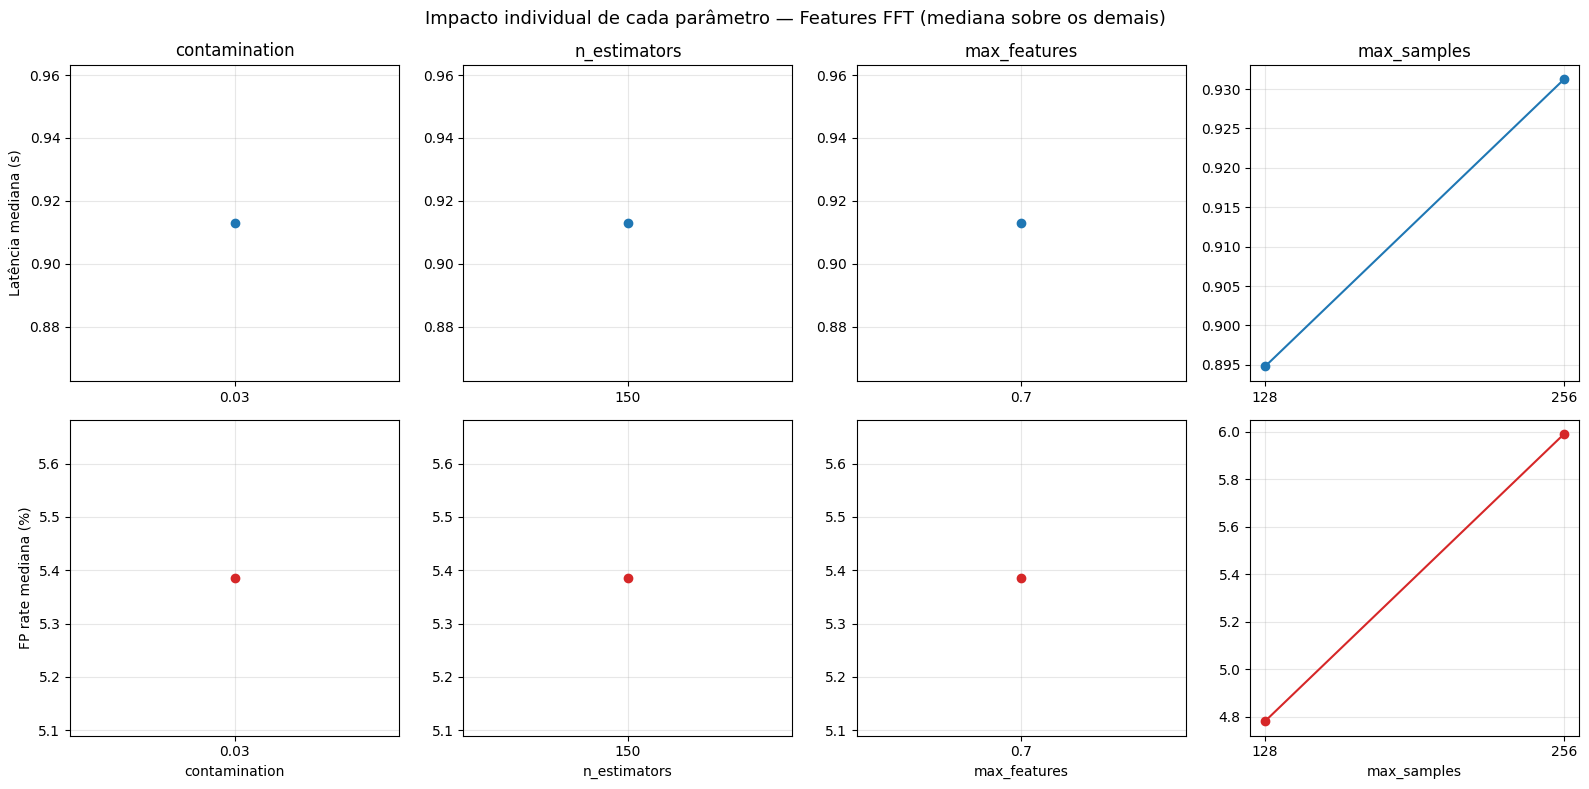

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
params_to_plot = ["contamination", "n_estimators", "max_features", "max_samples"]

for col, param in enumerate(params_to_plot):
    grp = df_det.groupby(param).agg(
        med_latency=("latency_s", "median"),
        med_fp_rate=("fp_rate", "median"),
    ).reset_index()

    ax_lat = axes[0, col]
    ax_fp  = axes[1, col]

    ax_lat.plot(grp[param].astype(str), grp["med_latency"], "o-", color="tab:blue")
    ax_lat.set_title(param)
    ax_lat.set_ylabel("Latência mediana (s)" if col == 0 else "")
    ax_lat.grid(True, alpha=0.3)

    ax_fp.plot(grp[param].astype(str), grp["med_fp_rate"] * 100, "o-", color="tab:red")
    ax_fp.set_ylabel("FP rate mediana (%)" if col == 0 else "")
    ax_fp.set_xlabel(param)
    ax_fp.grid(True, alpha=0.3)

fig.suptitle("Impacto individual de cada parâmetro — Features FFT (mediana sobre os demais)", fontsize=13)
plt.tight_layout()
plt.show()

## Heatmaps: interação entre parâmetros

Score composto mediano para pares de parâmetros, agregando sobre os demais.
Células mais escuras = melhor (menor score composto).

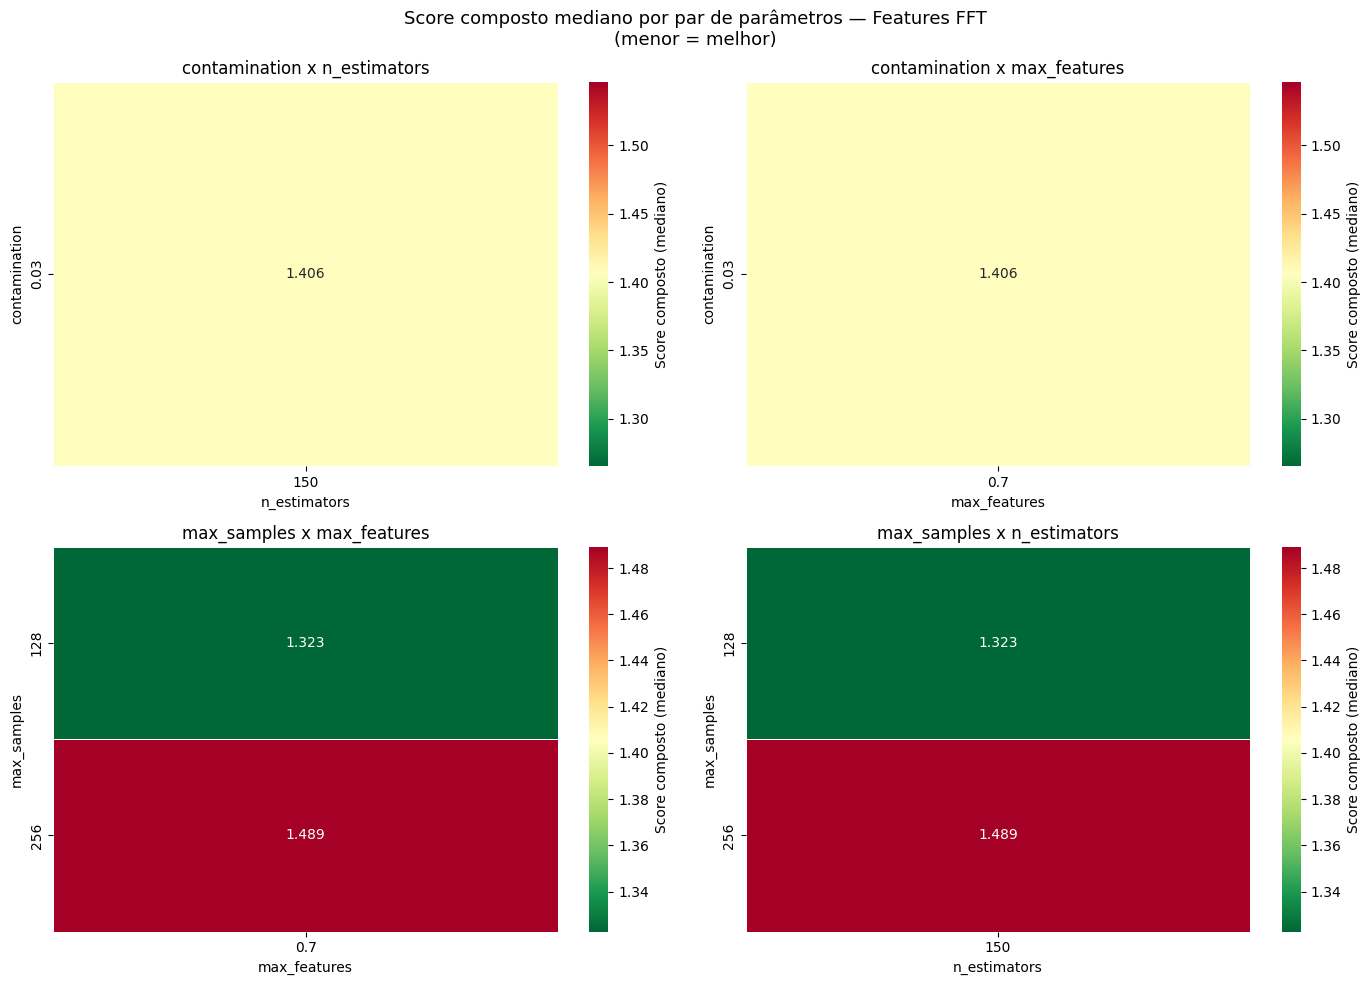

In [10]:
pairs = [
    ("contamination", "n_estimators"),
    ("contamination", "max_features"),
    ("max_samples",   "max_features"),
    ("max_samples",   "n_estimators"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (row_param, col_param) in zip(axes.flatten(), pairs):
    pivot = (
        df_det
        .groupby([row_param, col_param])["composite"]
        .median()
        .unstack(col_param)
    )
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".3f",
        cmap="RdYlGn_r", linewidths=0.5,
        cbar_kws={"label": "Score composto (mediano)"},
    )
    ax.set_title(f"{row_param} x {col_param}")
    ax.set_xlabel(col_param)
    ax.set_ylabel(row_param)

fig.suptitle("Score composto mediano por par de parâmetros — Features FFT\n(menor = melhor)", fontsize=13)
plt.tight_layout()
plt.show()

## Melhor configuração — análise detalhada

Visualiza o comportamento temporal do modelo com a melhor combinação de parâmetros.

Melhor configuração (menor score composto):
  contamination: 0.03
  n_estimators: 150
  max_features: 0.7
  max_samples: 128
  latency_s: 0.8947907840000013
  fp_count: 1607
  fp_rate: 0.0478216878942983
  composite: 1.322694840031427


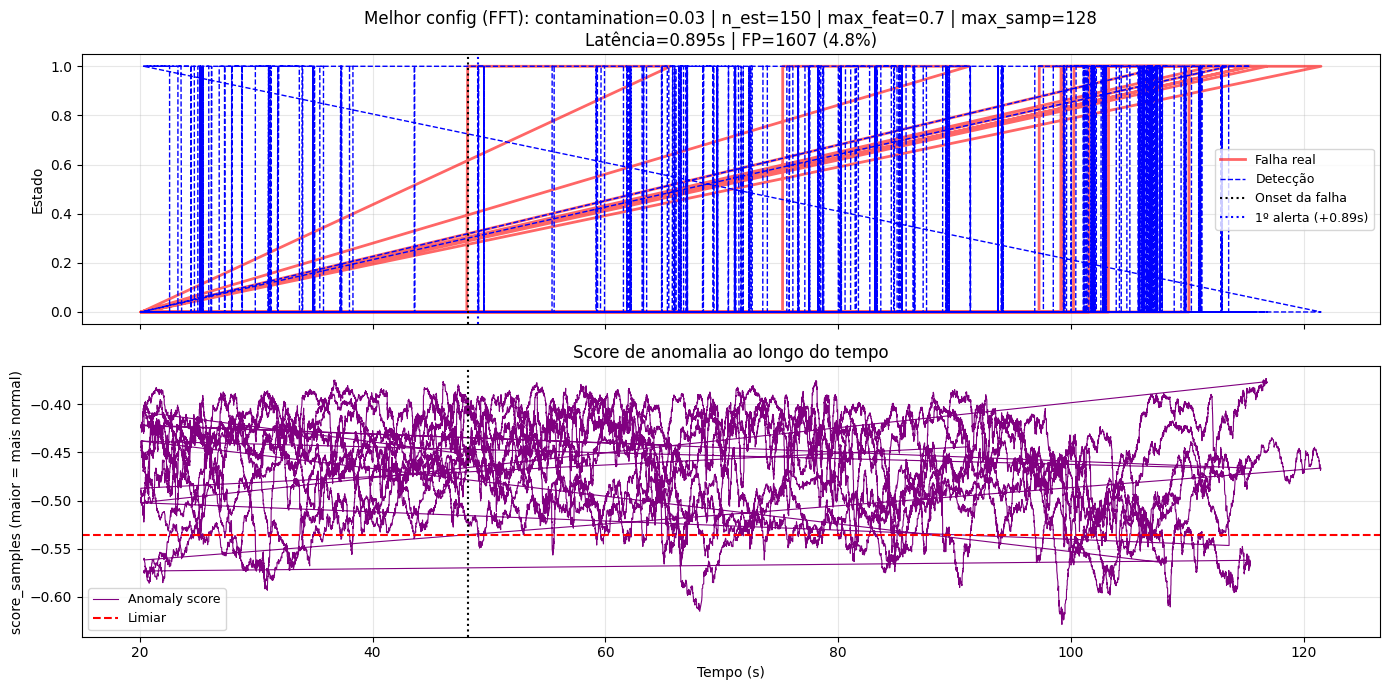

In [11]:
best = df_det.loc[df_det["composite"].idxmin()]
print("Melhor configuração (menor score composto):")
for k in ["contamination", "n_estimators", "max_features", "max_samples",
          "latency_s", "fp_count", "fp_rate", "composite"]:
    print(f"  {k}: {best[k]}")

best_model = IsolationForest(
    n_estimators=int(best["n_estimators"]),
    max_features=float(best["max_features"]),
    max_samples=int(best["max_samples"]),
    random_state=42,
    n_jobs=-1,
)
best_model.fit(X_train_scaled)

train_scores_best = best_model.score_samples(X_train_scaled)
test_scores_best  = best_model.score_samples(X_test_scaled)
threshold_best    = np.percentile(train_scores_best, 100 * best["contamination"])
y_pred_best       = (test_scores_best < threshold_best).astype(int)

post_fault = np.where(
    (y_pred_best == 1) & (np.arange(len(y_pred_best)) >= real_fault_idx)
)[0]
pred_fault_time = float(ts_test[post_fault[0]]) if len(post_fault) > 0 else None

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(ts_test, y_test,      color="red",  alpha=0.6, linewidth=2, label="Falha real")
axes[0].plot(ts_test, y_pred_best, color="blue", linestyle="--", linewidth=1, label="Detecção")
axes[0].axvline(real_fault_time, color="black", linewidth=1.5, linestyle=":", label="Onset da falha")
if pred_fault_time:
    axes[0].axvline(
        pred_fault_time, color="blue", linewidth=1.5, linestyle=":",
        label=f"1º alerta (+{best['latency_s']:.2f}s)",
    )
axes[0].set_ylabel("Estado")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_title(
    f"Melhor config (FFT): contamination={best['contamination']} | n_est={int(best['n_estimators'])} | "
    f"max_feat={best['max_features']} | max_samp={int(best['max_samples'])}\n"
    f"Latência={best['latency_s']:.3f}s | FP={int(best['fp_count'])} ({best['fp_rate']:.1%})"
)

axes[1].plot(ts_test, test_scores_best, color="purple", linewidth=0.8, label="Anomaly score")
axes[1].axhline(threshold_best, color="red", linestyle="--", linewidth=1.5, label="Limiar")
axes[1].axvline(real_fault_time, color="black", linewidth=1.5, linestyle=":")
axes[1].set_ylabel("score_samples (maior = mais normal)")
axes[1].set_xlabel("Tempo (s)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_title("Score de anomalia ao longo do tempo")

plt.tight_layout()
plt.show()

## Conclusão

Para aplicar a melhor configuração encontrada com features FFT, edite `conf/base/parameters.yml`:

```yaml
model_training:
  contamination: <melhor valor acima>
  n_estimators:  <melhor valor acima>
  # max_features e max_samples precisam ser expostos no pipeline
  # (ver nodes.py -> train_isolation_forest)
```

E rodar o pipeline FFT completo antes do treino:
```bash
kedro run --pipeline=fft_ingestion
kedro run --pipeline=fft_data_preparation
kedro run --pipeline=fft_feature_engineering
kedro run --pipeline=model_training
```

> **Nota:** Para usar as features FFT no pipeline `model_training` em produção, o catálogo
> precisa ser ajustado para apontar `feature_engineered_flights` para `data/04_feature/fft/`
> (ou criar um pipeline dedicado `fft_model_training` com sua própria entrada no catálogo).